In [5]:
from green_sinked import green_function_damped
import numpy as np
import matplotlib.pyplot as plt

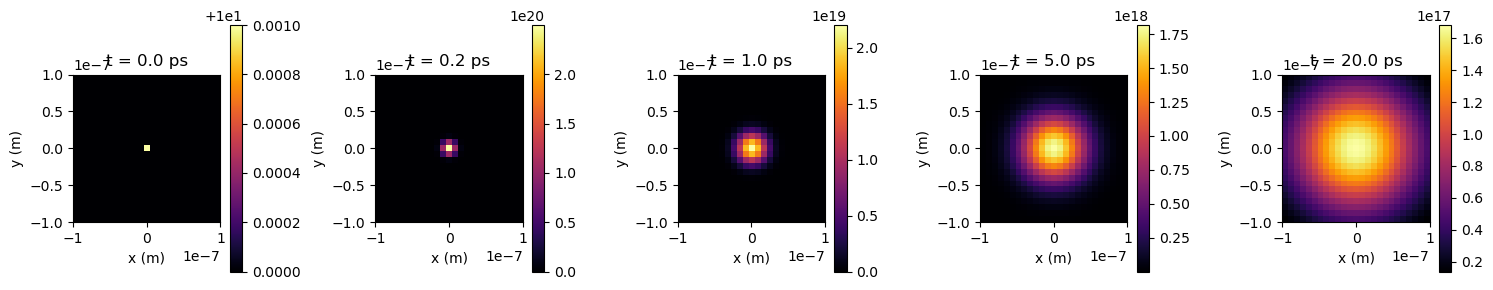

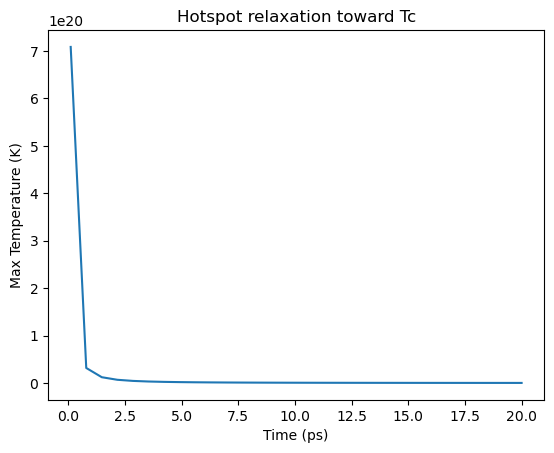

In [8]:
# ------------------------------------------------------------
# GRID SETUP
# ------------------------------------------------------------
nx, ny, nz = 25, 25, 25
L = 200e-9  # 200 nm cube

x = np.linspace(-L/2, L/2, nx)
y = np.linspace(-L/2, L/2, ny)
z = np.linspace(-L/2, L/2, nz)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")


# ------------------------------------------------------------
# INITIAL ENERGY DEPOSITION (single SRIM hotspot)
# ------------------------------------------------------------
E = np.zeros((nx, ny, nz))

# deposit at center voxel
E[nx//2, ny//2, nz//2] = 1e-3  # arbitrary energy unit


# ------------------------------------------------------------
# PHYSICAL PARAMETERS (NbN-like)
# ------------------------------------------------------------
D = 1e-4        # thermal diffusivity
tau = 50e-12    # relaxation time (50 ps)
Tc = 10.0       # Kelvin


# ------------------------------------------------------------
# TIME EVOLUTION
# ------------------------------------------------------------
times = [0.0, 0.2e-12, 1e-12, 5e-12, 20e-12]

results = []

for t in times:
    T = green_function_damped(E, X, Y, Z, D, t, tau, Tc)
    results.append(T)


# ------------------------------------------------------------
# VISUALIZATION: center slice evolution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(times), figsize=(15, 3))

for i, (t, T) in enumerate(zip(times, results)):

    im = axes[i].imshow(
        T[:, :, nz//2],
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        cmap="inferno"
    )

    axes[i].set_title(f"t = {t*1e12:.1f} ps")
    axes[i].set_xlabel("x (m)")
    axes[i].set_ylabel("y (m)")

    # show Tc reference implicitly via color contrast
    fig.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# DEBUG: track max temperature decay
# ------------------------------------------------------------
max_T = []

for t in np.linspace(0.1e-12, 20e-12, 30):
    T = green_function_damped(E, X, Y, Z, D, t, tau, Tc)
    max_T.append(T.max())

plt.figure()
plt.plot(np.linspace(0.1e-12, 20e-12, 30)*1e12, max_T)
plt.xlabel("Time (ps)")
plt.ylabel("Max Temperature (K)")
plt.title("Hotspot relaxation toward Tc")
plt.show()